# Metrics comparison between IK control solutions with teleoperation motions

## Imports 

In [49]:
import ast
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from metrics import l2_error, rodrigues_error
from reachy2_symbolic_ik.symbolic_ik import SymbolicIK
from reachy2_sdk import ReachySDK

In [54]:
symbolic_l = SymbolicIK(arm="l_arm")
symbolic_r = SymbolicIK(arm="r_arm")

Using default parameters
Using default parameters


In [ ]:
def parse_pose_matrix(matrix):
    """Convert a string of a matrix into a NumPy array."""
    if isinstance(matrix, str):
        return np.array(ast.literal_eval(matrix))
    else:
        return np.array(matrix)


def pose_matrix_to_goal(pose_mat):
    """
    pose_mat: 4x4 numpy array
    returns: np.array([position_list, [roll, pitch, yaw]]) where angles in radians
    """
    R = pose_mat[:3, :3]
    t = pose_mat[:3, 3].tolist()

    sy = math.sqrt(R[0, 0] ** 2 + R[1, 0] ** 2)
    singular = sy < 1e-6

    if not singular:
        roll = math.atan2(R[2, 1], R[2, 2])
        pitch = math.atan2(-R[2, 0], sy)
        yaw = math.atan2(R[1, 0], R[0, 0])
    else:
        roll = math.atan2(-R[1, 2], R[1, 1])
        pitch = math.atan2(-R[2, 0], sy)
        yaw = 0.0

    return np.array([t, [roll, pitch, yaw]], dtype=float)


def compute_fk_l(reachy, row):
    joints = np.rad2deg([row[f"l_q{i}"] for i in range(7)])
    M = reachy.l_arm.forward_kinematics(joints)
    return M.tolist()


def compute_fk_r(reachy, row):
    joints = np.rad2deg([row[f"r_q{i}"] for i in range(7)])
    M = reachy.r_arm.forward_kinematics(joints)
    return M.tolist()


def row_is_reachable_by_symbolic_ik(row, symbolic_l=symbolic_l, symbolic_r=symbolic_r):
    """
    Returns True if both (existing) left and right goals in the row are reachable
    according to the Symbolic IK.
    """
    reachable_l = True
    reachable_r = True

    if "l_pose" in row.index and str(row["l_pose"]) != "None":
        try:
            l_pose_mat = parse_pose_matrix(row["l_pose"])
            goal_l = pose_matrix_to_goal(l_pose_mat)
            is_reachable_l, _, _, _ = symbolic_l.is_reachable(goal_l)
            reachable_l = bool(is_reachable_l)
        except Exception as e:
            reachable_l = False

    if "r_pose" in row.index and str(row["r_pose"]) != "None":
        try:
            r_pose_mat = parse_pose_matrix(row["r_pose"])
            goal_r = pose_matrix_to_goal(r_pose_mat)
            is_reachable_r, _, _, _ = symbolic_r.is_reachable(goal_r)
            reachable_r = bool(is_reachable_r)
        except Exception as e:
            reachable_r = False

    return reachable_l and reachable_r


def compute_errors(df, lambda_theta=1e-6 / np.deg2rad(1) ** 2):
    if "l_pos_err" in df.columns and "r_pos_err" in df.columns:
        df["l_comb_err"] = np.sqrt(df["l_pos_err"] ** 2 + (lambda_theta * df["l_rot_err"] ** 2))
        df["r_comb_err"] = np.sqrt(df["r_pos_err"] ** 2 + (lambda_theta * df["r_rot_err"] ** 2))
        return df

    l_pos_errs, l_rot_errs = [], []
    r_pos_errs, r_rot_errs = [], []

    for _, row in df.iterrows():
        try:
            l_pose = parse_pose_matrix(row["l_pose"]) if row["l_pose"] != "None" else None
        except Exception:
            l_pose = None
        l_real = parse_pose_matrix(row["l_real_pose"])
        if l_pose is not None:
            l_pos_errs.append(l2_error(l_pose[:3, 3], l_real[:3, 3]))
            l_rot_errs.append(rodrigues_error(l_pose[:3, :3], l_real[:3, :3]))
        else:
            l_pos_errs.append(np.nan)
            l_rot_errs.append(np.nan)

        try:
            r_pose = parse_pose_matrix(row["r_pose"]) if row["r_pose"] != "None" else None
        except Exception:
            r_pose = None
        r_real = parse_pose_matrix(row["r_real_pose"])
        if r_pose is not None:
            r_pos_errs.append(l2_error(r_pose[:3, 3], r_real[:3, 3]))
            r_rot_errs.append(rodrigues_error(r_pose[:3, :3], r_real[:3, :3]))
        else:
            r_pos_errs.append(np.nan)
            r_rot_errs.append(np.nan)

    df["l_pos_err"] = l_pos_errs
    df["l_rot_err"] = l_rot_errs
    df["r_pos_err"] = r_pos_errs
    df["r_rot_err"] = r_rot_errs
    df["l_comb_err"] = np.sqrt(df["l_pos_err"] ** 2 + (lambda_theta * df["l_rot_err"] ** 2))
    df["r_comb_err"] = np.sqrt(df["r_pos_err"] ** 2 + (lambda_theta * df["r_rot_err"] ** 2))
    return df


def compute_reachability_flags(df, symbolic_l=symbolic_l, symbolic_r=symbolic_r):
    l_flags, r_flags = [], []
    for _, row in df.iterrows():
        reachable_l = False
        if "l_pose" in row.index and str(row["l_pose"]) != "None":
            try:
                l_pose_mat = parse_pose_matrix(row["l_pose"])
                goal_l = pose_matrix_to_goal(l_pose_mat)
                is_reachable_l, _, _, _ = symbolic_l.is_reachable(goal_l)
                reachable_l = bool(is_reachable_l)
            except Exception:
                reachable_l = False
        else:
            reachable_l = False

        reachable_r = False
        if "r_pose" in row.index and str(row["r_pose"]) != "None":
            try:
                r_pose_mat = parse_pose_matrix(row["r_pose"])
                goal_r = pose_matrix_to_goal(r_pose_mat)
                is_reachable_r, _, _, _ = symbolic_r.is_reachable(goal_r)
                reachable_r = bool(is_reachable_r)
            except Exception:
                reachable_r = False
        else:
            reachable_r = False

        l_flags.append(reachable_l)
        r_flags.append(reachable_r)

    df = df.copy()
    df["l_reachable"] = np.array(l_flags, dtype=bool)
    df["r_reachable"] = np.array(r_flags, dtype=bool)
    return df

## Position comparison between Desired pose and Real pose  

In [52]:
filepath = "data/sym_heart_live.csv"

reachy = ReachySDK(host="localhost")
df = pd.read_csv(filepath, sep=",", header=0).copy()
df = df.dropna()

df["l_real_pose"] = df.apply(lambda row: compute_fk_l(reachy, row), axis=1)
df["r_real_pose"] = df.apply(lambda row: compute_fk_r(reachy, row), axis=1)
df.reset_index(drop=True, inplace=True)

reachy.disconnect()

Reachy gRPC stream is shutting down.


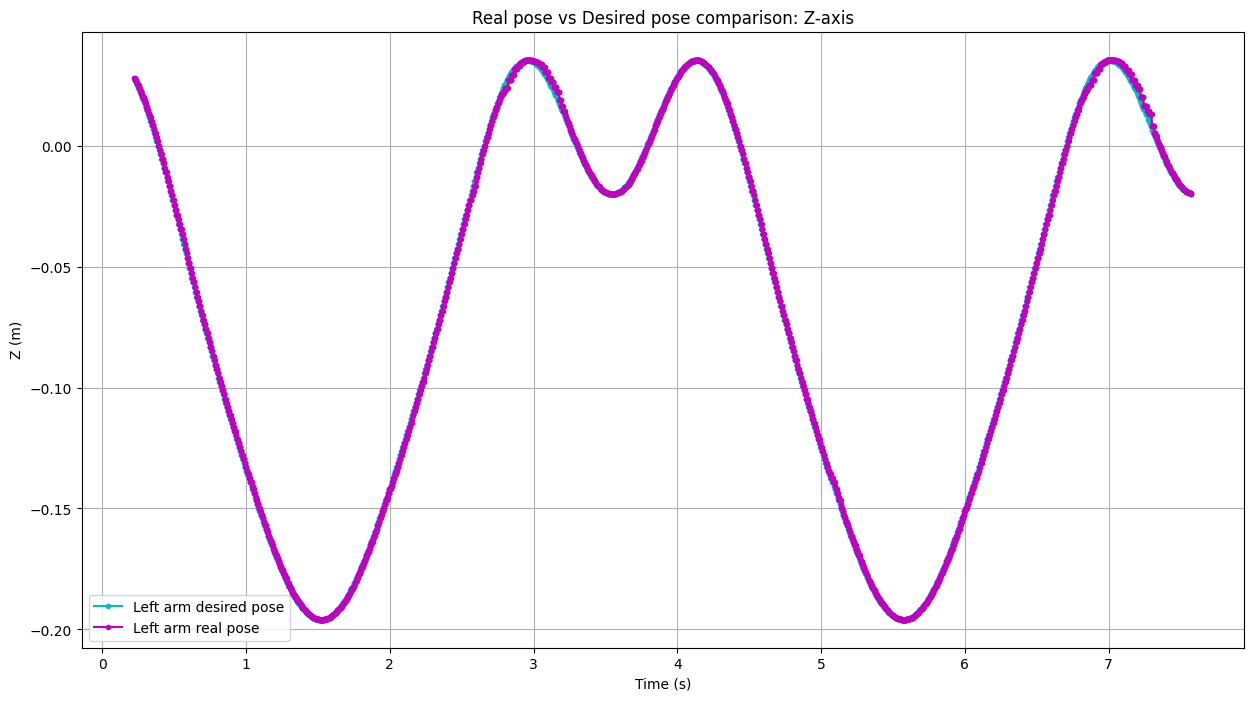

In [59]:
coord_idx = 2  # 0, 1, 2 for X, Y, Z

a, b = 100, None
pose_slice = slice(a, None if b is None else b - 1)
time_slice = slice(a + 1, None if b is None else b)

plt.figure(figsize=(15, 8))
L_POSE_LST = []
L_POSE_REAL_LST = []
for i in range(1, len(df)):
    l_pose = parse_pose_matrix(df["l_pose"][i])[coord_idx][3]
    l_pose_real = parse_pose_matrix(df["l_real_pose"][i])[coord_idx][3]
    L_POSE_LST.append(l_pose)
    L_POSE_REAL_LST.append(l_pose_real)
plt.plot(df["time"][time_slice], L_POSE_LST[pose_slice], label="Left arm desired pose", color="c", marker=".")
plt.plot(df["time"][time_slice], L_POSE_REAL_LST[pose_slice], label="Left arm real pose", color="m", marker=".")
plt.grid()
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel(f"{"XYZ"[coord_idx]} (m)")
plt.title(f"Real pose vs Desired pose comparison: {"XYZ"[coord_idx]}-axis")
plt.show()

## IK control solutions comparison

### Computing Real poses

### Metrics comparison

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# params
test = "basket_grab"
paths = {
    "Symbolic IK": f"data/sym_{test}.csv",
    "Jacobian IK": f"data/sym_{test}.csv",
    "QP IK": f"data/qp_{test}.csv",
}

lambda_theta = 1e-6 / np.deg2rad(1) ** 2

dfs_dict = {}
for name, p in paths.items():
    df_tmp = pd.read_csv(p, sep=",", header=0).copy().dropna().reset_index(drop=True)
    df_tmp = compute_errors(df_tmp)
    dfs_dict[name] = df_tmp

order = ["Symbolic IK", "Jacobian IK", "QP IK"]
dfs_list = [(dfs_dict[name], name) for name in order]


for i, (df_tmp, title) in enumerate(dfs_list):
    dfs_list[i] = (compute_reachability_flags(df_tmp), title)

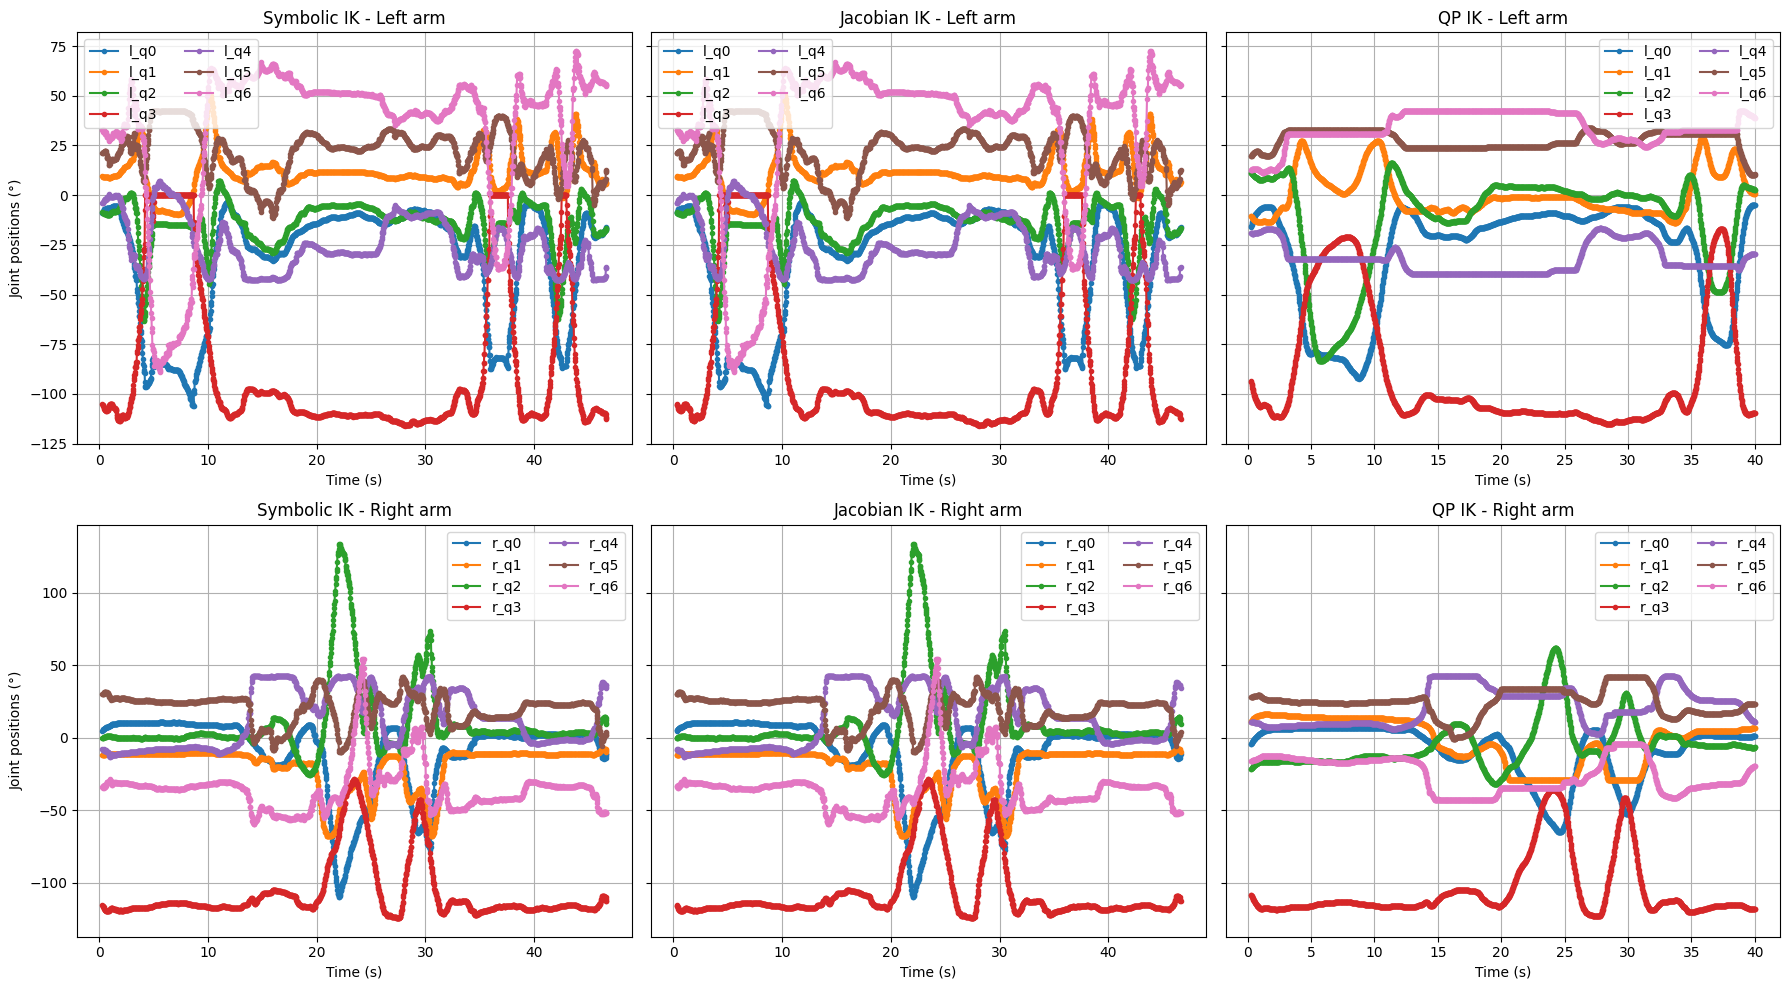

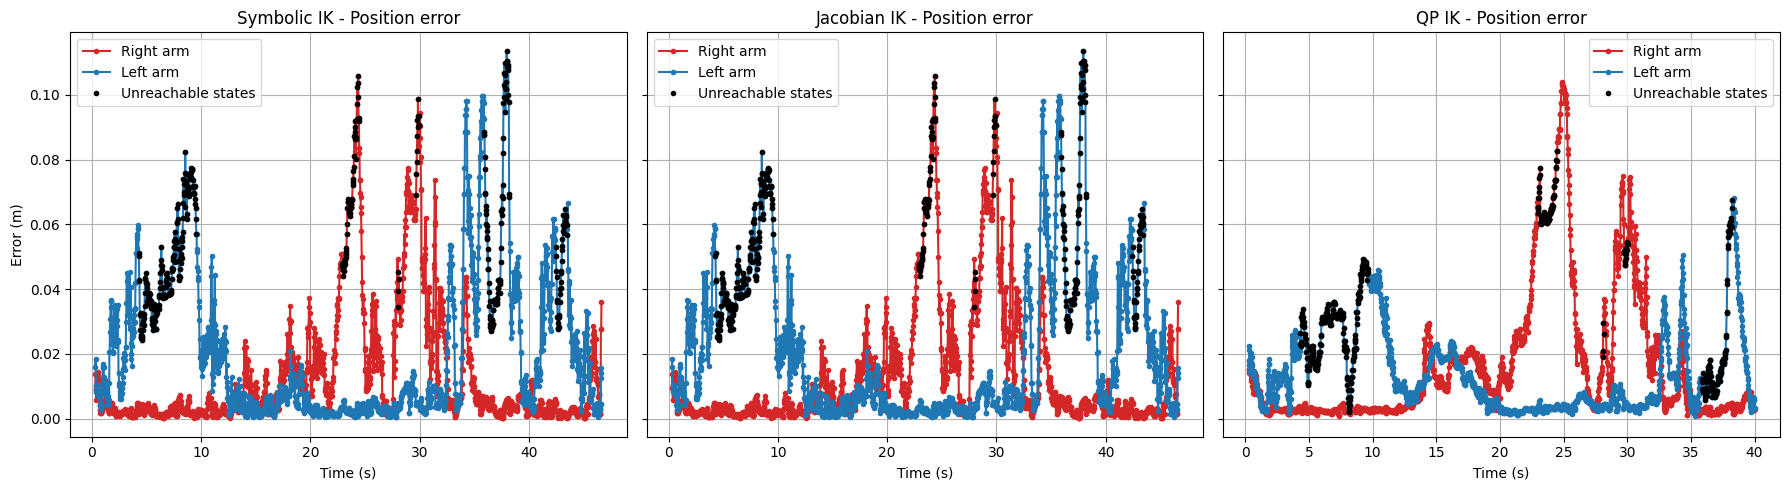

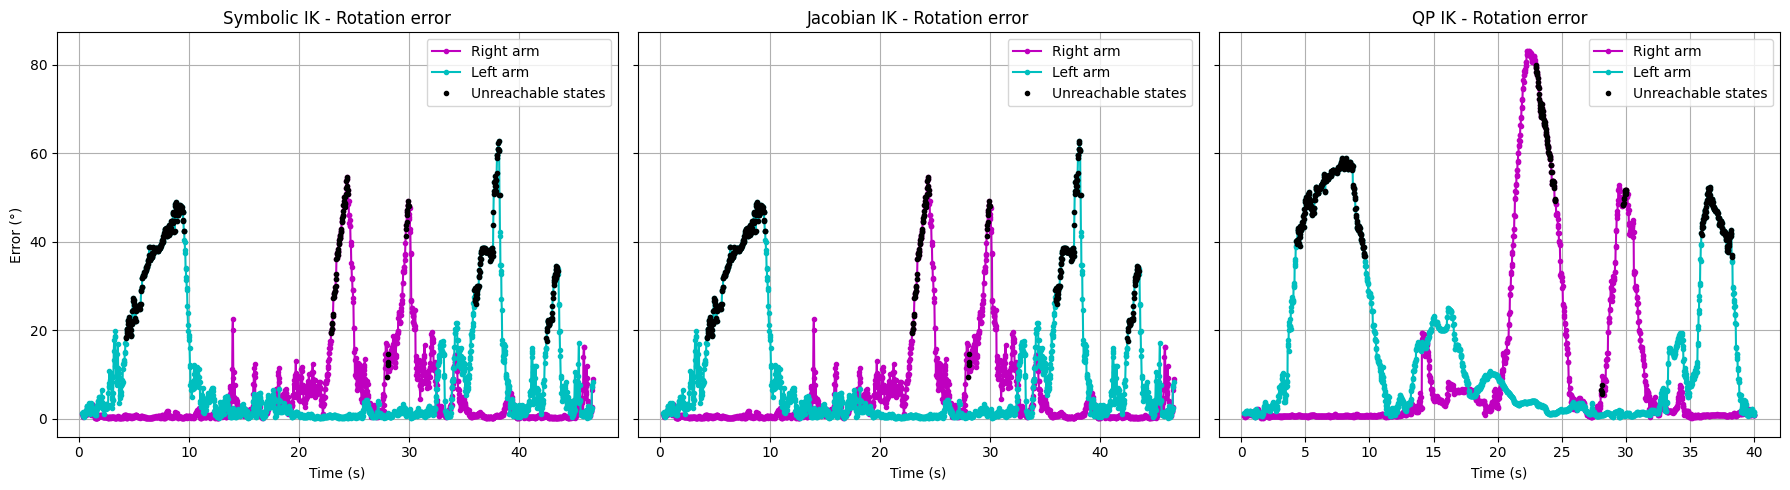

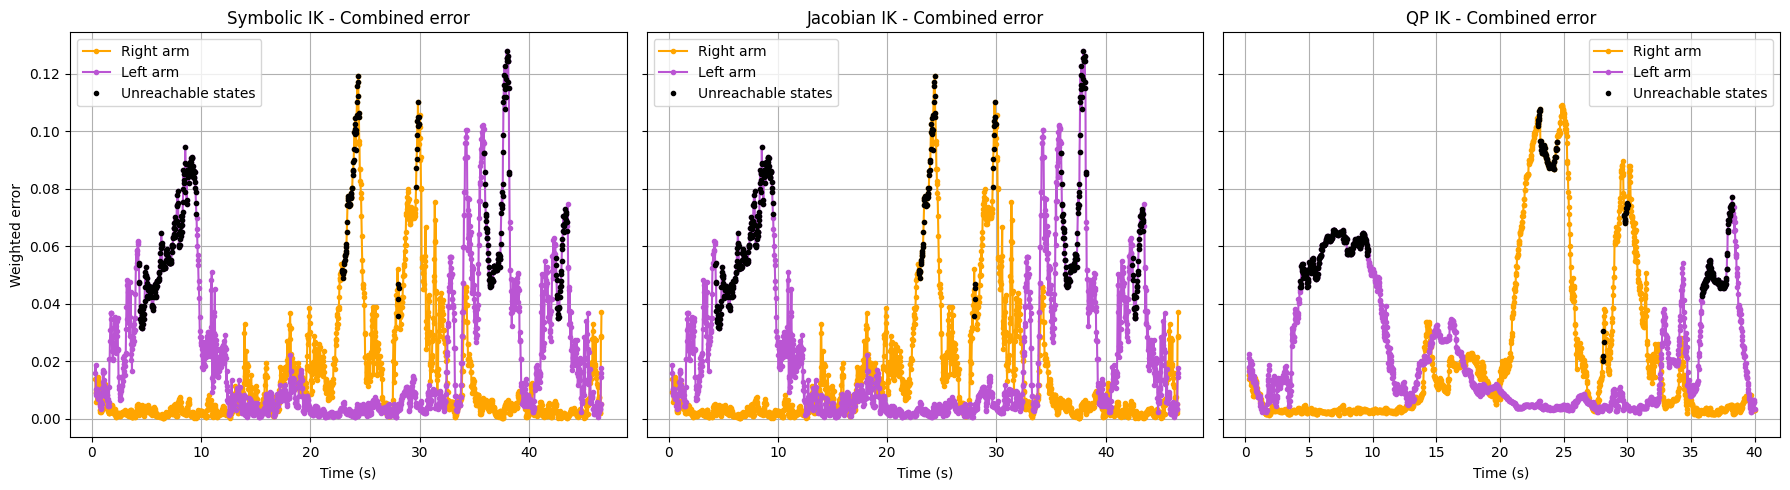

In [97]:
time_slice = slice(10, None)

l_cols = [f"l_q{i}" for i in range(7)]
r_cols = [f"r_q{i}" for i in range(7)]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey="row")
for idx, (df_tmp, title) in enumerate(dfs_list):
    for col in l_cols:
        if col in df_tmp.columns:
            axes[0, idx].plot(df_tmp["time"][time_slice], df_tmp[col][time_slice], marker=".", label=col)
    axes[0, idx].set_title(f"{title} - Left arm")
    axes[0, idx].set_xlabel("Time (s)")
    if idx == 0:
        axes[0, idx].set_ylabel("Joint positions (°)")
    axes[0, idx].grid(True)
    axes[0, idx].legend(l_cols, ncol=2)

    for col in r_cols:
        if col in df_tmp.columns:
            axes[1, idx].plot(df_tmp["time"][time_slice], df_tmp[col][time_slice], marker=".", label=col)
    axes[1, idx].set_title(f"{title} - Right arm")
    axes[1, idx].set_xlabel("Time (s)")
    if idx == 0:
        axes[1, idx].set_ylabel("Joint positions (°)")
    axes[1, idx].grid(True)
    axes[1, idx].legend(r_cols, ncol=2)
fig.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for idx, (df_tmp, title) in enumerate(dfs_list):
    sub = df_tmp.iloc[time_slice]
    axes[idx].plot(sub["time"], sub["r_pos_err"], marker=".", label="Right arm", color="tab:red")
    unreachable_r = ~sub["r_reachable"].to_numpy(dtype=bool)
    if unreachable_r.any():
        axes[idx].plot(
            sub["time"][unreachable_r], sub["r_pos_err"].to_numpy()[unreachable_r], linestyle="None", marker=".", color="black"
        )
    axes[idx].plot(sub["time"], sub["l_pos_err"], marker=".", label="Left arm", color="tab:blue")
    unreachable_l = ~sub["l_reachable"].to_numpy(dtype=bool)
    if unreachable_l.any():
        axes[idx].plot(
            sub["time"][unreachable_l],
            sub["l_pos_err"].to_numpy()[unreachable_l],
            linestyle="None",
            marker=".",
            color="black",
            label="Unreachable states",
        )
    axes[idx].set_title(f"{title} - Position error")
    axes[idx].set_xlabel("Time (s)")
    if idx == 0:
        axes[idx].set_ylabel("Error (m)")
    axes[idx].legend()
    axes[idx].grid(True)
fig.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for idx, (df_tmp, title) in enumerate(dfs_list):
    sub = df_tmp.iloc[time_slice]
    axes[idx].plot(sub["time"], np.rad2deg(sub["r_rot_err"]), marker=".", label="Right arm", color="m")
    unreachable_r = ~sub["r_reachable"].to_numpy(dtype=bool)
    if unreachable_r.any():
        axes[idx].plot(
            sub["time"][unreachable_r],
            np.rad2deg(sub["r_rot_err"].to_numpy()[unreachable_r]),
            linestyle="None",
            marker=".",
            color="black",
        )
    axes[idx].plot(sub["time"], np.rad2deg(sub["l_rot_err"]), marker=".", label="Left arm", color="c")
    unreachable_l = ~sub["l_reachable"].to_numpy(dtype=bool)
    if unreachable_l.any():
        axes[idx].plot(
            sub["time"][unreachable_l],
            np.rad2deg(sub["l_rot_err"].to_numpy()[unreachable_l]),
            linestyle="None",
            marker=".",
            color="black",
            label="Unreachable states",
        )

    axes[idx].set_title(f"{title} - Rotation error")
    axes[idx].set_xlabel("Time (s)")
    if idx == 0:
        axes[idx].set_ylabel("Error (°)")
    axes[idx].legend()
    axes[idx].grid(True)
fig.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for idx, (df_tmp, title) in enumerate(dfs_list):
    sub = df_tmp.iloc[time_slice]
    comb_l = np.sqrt(sub["l_pos_err"].to_numpy() ** 2 + (lambda_theta * sub["l_rot_err"].to_numpy() ** 2))
    comb_r = np.sqrt(sub["r_pos_err"].to_numpy() ** 2 + (lambda_theta * sub["r_rot_err"].to_numpy() ** 2))

    axes[idx].plot(sub["time"], comb_r, marker=".", label="Right arm", color="orange")
    unreachable_r = ~sub["r_reachable"].to_numpy(dtype=bool)
    if unreachable_r.any():
        axes[idx].plot(
            sub["time"][unreachable_r],
            comb_r[unreachable_r],
            linestyle="None",
            marker=".",
            color="black",
        )
    axes[idx].plot(sub["time"], comb_l, marker=".", label="Left arm", color="mediumorchid")
    unreachable_l = ~sub["l_reachable"].to_numpy(dtype=bool)
    if unreachable_l.any():
        axes[idx].plot(
            sub["time"][unreachable_l],
            comb_l[unreachable_l],
            linestyle="None",
            marker=".",
            color="black",
            label="Unreachable states",
        )

    axes[idx].set_title(f"{title} - Combined error")
    axes[idx].set_xlabel("Time (s)")
    if idx == 0:
        axes[idx].set_ylabel("Weighted error")
    axes[idx].legend()
    axes[idx].grid(True)
fig.tight_layout()
plt.show()